In [8]:
import sys
print(sys.executable)


C:\Users\ADMIN\anaconda3\python.exe


In [9]:
!pip show scikit-learn


Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [11]:
import sklearn
print(sklearn.__version__)

1.6.1


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


--- CLEANED TEXT EXAMPLE ---
{'text': 'The new smartphone has a massive battery life and OLED screen.', 'clean_text': 'new smartphone massive battery life oled screen'} 

--- TEXT CONVERTED TO NUMBERS (TF-IDF MATRIX SHAPE) ---
Dataset Shape: (6, 40) (6 articles, 40 unique important words)

--- MODEL PERFORMANCE ---
Accuracy Score: 66.67%
X shape: (6, 40)
Actual: ['Sports', 'Tech', 'Business']
Predicted: [np.str_('Tech'), np.str_('Tech'), np.str_('Business')]
Accuracy: 0.6666666666666666
Actual: ['Sports', 'Tech', 'Business']
Predicted: [np.str_('Tech'), np.str_('Tech'), np.str_('Business')]


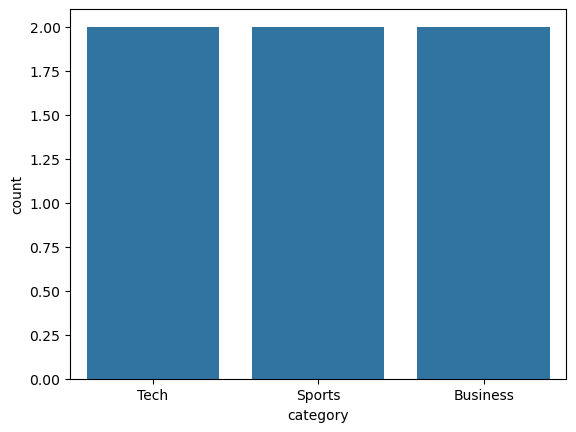

In [22]:
import pandas as pd 
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import nltk 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report 
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
news_data = {
    'text': [
        "The new smartphone has a massive battery life and OLED screen.",
        "The football match ended in a thrilling 2-2 draw last night.",
        "Stock market shares crashed today after the inflation report.",
        "Microsoft is launching a new AI feature for its operating system.",
        "The Olympics committee announced new rules for the swimming events.",
        "The central bank raised interest rates to control economic inflation."
    ],
    'category': ['Tech', 'Sports', 'Business', 'Tech', 'Sports', 'Business']
}
df=pd.DataFrame(news_data)
def clean_text(text):
    tokens = word_tokenize(text.lower())
    cleaned = [
         lemmatizer.lemmatize(word)
         for word in tokens
         if word.isalpha() and word not in stop_words
    ]
    return " ".join(cleaned)
df['clean_text'] = df['text'].apply(clean_text)
print("--- CLEANED TEXT EXAMPLE ---")
print(df[['text', 'clean_text']].iloc[0].to_dict(), "\n")
tfidf=TfidfVectorizer()
x=tfidf.fit_transform(df['clean_text']).toarray()
y=df['category']
print("--- TEXT CONVERTED TO NUMBERS (TF-IDF MATRIX SHAPE) ---")
print(f"Dataset Shape: {x.shape} (6 articles, {x.shape[1]} unique important words)\n")
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.5,random_state=42, stratify=y)
model= MultinomialNB()
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print("--- MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, prediction) * 100:.2f}%")
print("X shape:", x.shape)
print("Actual:", list(y_test))
print("Predicted:", list(prediction))
print("Accuracy:", accuracy_score(y_test, prediction))
print("Actual:", list(y_test))
print("Predicted:", list(prediction))
sns.countplot(data=df, x='category')
plt.show()


    

     
    
    
    
    
    

